# SPAD ODMR Ensemble — Notebook README

> **Goal**: Load and process SPAD ODMR acquisitions saved as `.spc3` (optionally using a pre-exported processed `.npz`), compute per-frequency averaged signal/reference images, apply optional background subtraction, and plot ODMR/ROI diagnostics.

---
## Inputs (choose one path)

### A) **Fast path (recommended): load pre-processed export**
- Set `spad_processed_file` (Cell 4) to the exported base name (or filename) of a processed `.npz` created by the **“export processed data”** cell.
- The loader searches these locations:
  - exact path you provide
  - `<spad_dir>/processed/<name>.npz`
- When this path is used, the notebook loads:
  - `sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`, `f_vec`, `n_complete_reps`, and `bg_avg_cps` (if present)
  - references from the companion header text (`*_header.txt`) such as the original SPC3 file and QM dataset path

### B) **Full path: load raw `.spc3` and process in this notebook**
- Set `spad_processed_file = None` (Cell 3).
- Set these (Cell 3):
  - `spc3_file_header` (prefix for continuous acquisition files)
  - `qm_file` (QM dataset path relative to `qm_dir`)
  - `spad_background` (optional background `.spc3` stem, or `None`)
- The notebook will find all part-files matching `<spc3_file_header><integer>.spc3` under `<spad_dir>/spc3/` and average complete repetitions.

---
## What you get in memory
- `sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`: arrays shaped `(F, n_rows, n_cols)` in counts/sec/pixel (optionally background-subtracted).
- `f_vec`: frequency axis (Hz).
- `n_complete_reps`: number of complete repetitions included in the averages.
- `bg_avg_cps`: background image in counts/sec/pixel (or `None`).
- `header`: SPAD measurement header metadata (from the raw `.spc3` file OR reconstructed from the processed export).
- `integration_time_s`: exposure/integration time used to convert counts → cps (gated/ungated logic).

---
## Outputs written to disk (optional)
The **“export processed data”** cell saves to `<spad_dir>/processed/`:
- `<base_name>.npz` (arrays)
- `<base_name>_header.txt` (JSON-rich metadata header for provenance)

---
## How to run
1. Run Cells 1–4 to set imports/paths and optionally load processed data.
2. If using raw SPC3: run the subsequent cells in order (QM metadata → SPC3 discovery → header read → background → accumulation).
3. Use the plotting/ROI cells at the end for diagnostics.

---
## Notes / troubleshooting
- If `spad_processed_file` is set but not found, the loader prints the locations it tried and raises `FileNotFoundError`.
- If you change `spad_background`, re-run the background and downstream processing cells so `bg_avg_cps` stays consistent.
- If you’re using processed exports, downstream cells that depend on QM-only variables (e.g. `f_mw_hz`/`f_mhz`) may still need a minimal QM load depending on what you plot.

In [204]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from types import SimpleNamespace
from pathlib import Path
import re
from spc import SPC3
from qua_tools_nv2.dataset import DatasetReader
from importlib import reload
import nv2_analysis.fits as fits


In [205]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

In [260]:

#spad_processed_files = {'spc3_continuous_20260420-111826-831402__166_pulsed_odmr_162919_avg.npz','spc3_continuous_20260420-121425-770239__166_pulsed_odmr_162919_avg.npz'}

spad_processed_files = {'spc3_continuous_20260518-120115-998225__225_cw_odmr_101745_avg.npz'} #40 mW
spad_processed_files = {'spc3_continuous_20260518-135437-022759__225_cw_odmr_101745_avg.npz'} #50 mW
spad_processed_files = {'spc3_continuous_20260518-104550-384679__225_cw_odmr_101745_avg.npz'} #60 mW
spad_processed_files = {'spc3_continuous_20260518-113501-037869__225_cw_odmr_101745_avg.npz'} #70 mW
spad_processed_files = {'spc3_continuous_20260518-100651-686549__225_cw_odmr_101745_avg.npz'} #80 mW
spad_processed_files = {'spc3_continuous_20260518-125924-810193__225_cw_odmr_101745_avg.npz'} #100 mW
spad_processed_files = {'spc3_continuous_20260518-131924-839376__225_cw_odmr_101745_avg.npz'} #120 mW


In [261]:
# Load processed SPAD arrays (if available)
# Expected keys (written by the "export processed data" cell):
#   sig_avg_cps_bgsub, ref_avg_cps_bgsub, f_vec, n_complete_reps, bg_avg_cps

processed_loaded = False
spc3_file_0 = None
qm_file_from_processed = None
processed_metadata_export = None

def _load_processed_header_txt(header_path: Path) -> dict:
    """Parse the *_header.txt created by the export cell and return the JSON dict."""
    text = header_path.read_text(encoding='utf-8')
    json_start = text.find('{')
    if json_start < 0:
        raise ValueError(f"No JSON object found in header file: {header_path}")
    return json.loads(text[json_start:])


processed_dir = Path(spad_dir) / 'processed'

sig_avg_cps_bgsub_all = []
ref_avg_cps_bgsub_all = []
n_complete_reps_all = []
diff_sig_all = []

for spad_processed_file in spad_processed_files:
    spf = Path(spad_processed_file)
    spf_npz = spf if spf.suffix.lower() == '.npz' else spf.with_suffix('.npz')

    candidates = [
        spf,
        spf_npz,
        processed_dir / spf.name,
        processed_dir / spf_npz.name,
    ]

    processed_path = next((p for p in candidates if p.exists()), None)
    if processed_path is None:
        cand_str = "\n".join(f"  - {p}" for p in candidates)
        raise FileNotFoundError(
            "spad_processed_file was set, but no processed .npz was found. Tried:\n" + cand_str
        )

    print(f"Loading processed arrays from: {processed_path}")

    with np.load(processed_path, allow_pickle=True) as npz:
        sig_avg_cps_bgsub = np.asarray(npz['sig_avg_cps_bgsub'])
        ref_avg_cps_bgsub = np.asarray(npz['ref_avg_cps_bgsub'])
        f_vec = np.asarray(npz['f_vec'])
        n_complete_reps = int(np.asarray(npz['n_complete_reps']).item())

    processed_loaded = True

    print(
        "Loaded processed arrays:\n"
        f"  sig_avg_cps_bgsub: {sig_avg_cps_bgsub.shape}\n"
        f"  ref_avg_cps_bgsub: {ref_avg_cps_bgsub.shape}\n"
        f"  f_vec           : {f_vec.shape}\n"
        f"  n_complete_reps : {n_complete_reps}\n"
    )

    # Load companion header file and extract references
    processed_header_path = processed_path.parent / f"{processed_path.stem}_header.txt"
    if processed_header_path.exists():
        processed_metadata_export = _load_processed_header_txt(processed_header_path)
        spc3_file_0 = (
            processed_metadata_export.get('spc3_data', {}).get('spc3 file 0')
            if isinstance(processed_metadata_export, dict)
            else None
        )
        qm_file_from_processed = (
            processed_metadata_export.get('run_info', {}).get('qm_file')
            if isinstance(processed_metadata_export, dict)
            else None
        )

        #print(
        #    "Loaded processed header references:\n"
        #    f"  spc3 file 0: {spc3_file_0}\n"
        #    f"  qm file    : {qm_file_from_processed}"
        #)
    sig_avg_cps_bgsub_all.append(sig_avg_cps_bgsub)
    ref_avg_cps_bgsub_all.append(ref_avg_cps_bgsub)
    n_complete_reps_all.append(n_complete_reps)

    # with np.errstate(divide='ignore', invalid='ignore'):
    #     norm_sig = np.where(
    #         sig_avg_cps_bgsub != 0,
    #         (sig_avg_cps_bgsub - ref_avg_cps_bgsub) / sig_avg_cps_bgsub,
    #         0.0
    #     )
    # norm_sig_all.append(norm_sig)
    diff_sig_all.append(sig_avg_cps_bgsub - ref_avg_cps_bgsub)

n_total = np.sum(n_complete_reps_all)
print(f"Total number of complete repetitions across all processed files: {n_total}")

sig_avg_cps_bgsub_all = np.array(sig_avg_cps_bgsub_all)
ref_avg_cps_bgsub_all = np.array(ref_avg_cps_bgsub_all)

#to do: weighted average by n_complete_reps_all
sig_avg = np.mean(sig_avg_cps_bgsub_all, axis=0) 
ref_avg = np.mean(ref_avg_cps_bgsub_all, axis=0) 

diff_sig_avg = np.mean(diff_sig_all, axis=0) 



Loading processed arrays from: C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\spc3_continuous_20260518-131924-839376__225_cw_odmr_101745_avg.npz
Loaded processed arrays:
  sig_avg_cps_bgsub: (60, 32, 32)
  ref_avg_cps_bgsub: (60, 32, 32)
  f_vec           : (60,)
  n_complete_reps : 249999

Total number of complete repetitions across all processed files: 249999


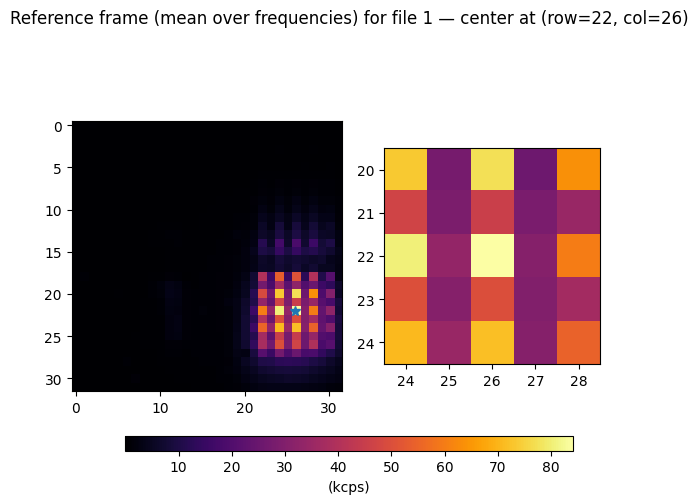

In [262]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
n = 5  # size of ROI (n x n pixels)

for k in range(len(n_complete_reps_all)):

    ref_frame = ref_avg_cps_bgsub_all[k,:,:].mean(axis =0)  # (rows, cols) — mean reference over all frequencies
    bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
    #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(1e-3*ref_frame, cmap='inferno')
    plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)

    plt.subplot(1, 2, 2)
    plt.imshow(1e-3*ref_frame, cmap='inferno')
    plt.xlim(bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5)
    plt.ylim(bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5)
    plt.colorbar(label='(kcps)')
    # Replace the per-subplot colorbar with a single shared colorbar (horizontal, bottom)
    fig = plt.gcf()

    # First two axes are the image subplots; any additional axes are the colorbar axes we just created
    ax1, ax2 = fig.axes[0], fig.axes[1]
    for ax_extra in list(fig.axes[2:]):
        ax_extra.remove()

    im1 = ax1.images[-1]
    im2 = ax2.images[-1]
    im2.set_norm(im1.norm)  # ensure both subplots share the same normalization

    # Add a dedicated colorbar axes at the bottom; exclude from tight_layout calculations
    cax = fig.add_axes([0.15, 0.06, 0.70, 0.03])
    cax.set_in_layout(False)

    cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
    cbar.set_label("(kcps)")
    plt.suptitle(f'Reference frame (mean over frequencies) for file {k+1} — center at (row={bright_rc[0]}, col={bright_rc[1]})')
    plt.tight_layout()

plt.show()

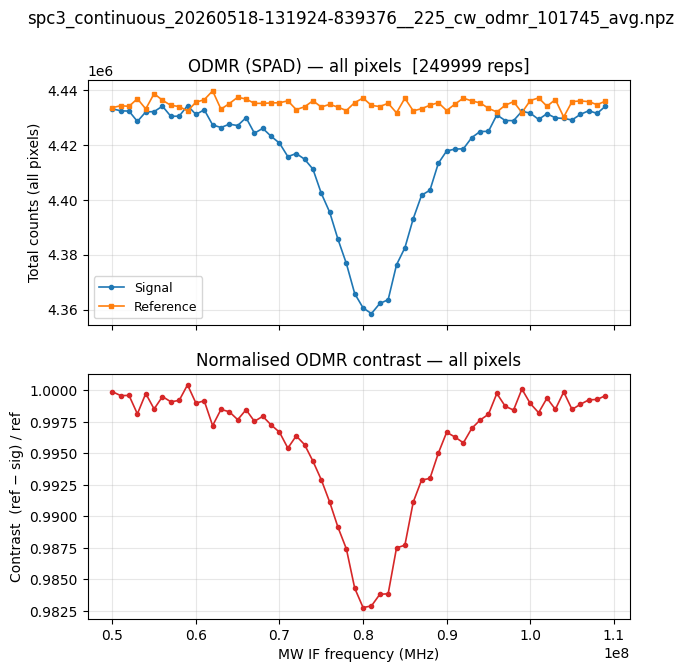

In [263]:
for k in range(len(spad_processed_files)):
    sig_counts  = sig_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)
    ref_counts  = ref_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)

    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_all = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    
    plt.suptitle(f'{list(spad_processed_files)[k]}')
    axes[0].plot(f_vec, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
    axes[0].plot(f_vec, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
    axes[0].set_ylabel('Total counts (all pixels)')
    axes[0].set_title(f'ODMR (SPAD) — all pixels  [{n_complete_reps_all[k]} reps]')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(f_vec, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
    axes[1].set_xlabel('MW IF frequency (MHz)')
    axes[1].set_ylabel('Contrast  (ref − sig) / ref')
    axes[1].set_title('Normalised ODMR contrast — all pixels')
    axes[1].grid(True, alpha=0.3)
    #axes[1].set_ylim([0.96, 1.01])

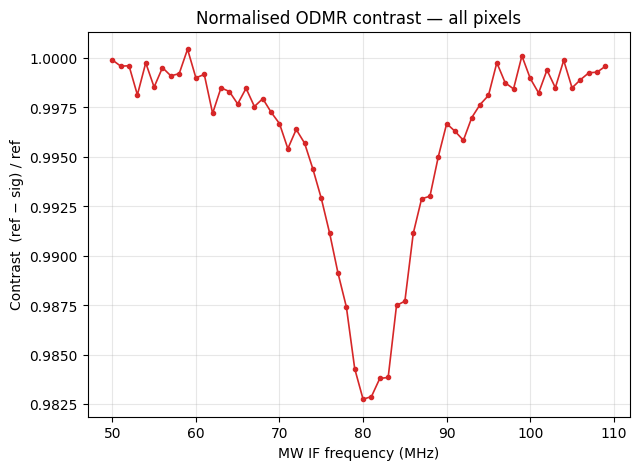

In [264]:
contrast_all = []

for k in range(len(n_complete_reps_all)):
    sig_counts  = sig_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)
    ref_counts  = ref_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)

    with np.errstate(divide='ignore', invalid='ignore'):
        contrast = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

    contrast_all.append(contrast)

contrast_all = np.array(contrast_all)
contrast_ave = np.mean(contrast_all, axis=0)

plt.figure(figsize=(7, 5))

plt.plot(f_vec/1e6, contrast_ave, 'o-', ms=3, lw=1.2, color='C3')
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('Contrast  (ref − sig) / ref')
plt.title('Normalised ODMR contrast — all pixels')
#plt.ylim([0.97, 1.01])
plt.grid(True, alpha=0.3)

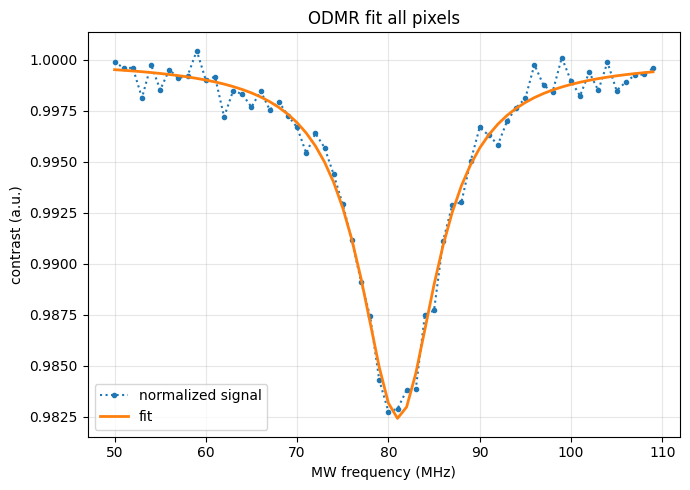

Fit results:
- f0: 81.075479 MHz
- FWHM: 10.168560 MHz
- amplitude: 0.0175455
- Residual RMS: 0.00063868
- SNR: 27.47


In [265]:
#fit lorentzian to contrast_ave vs f_vec to find resonance frequency

reload(fits)
fitter = fits.ExperimentFitter()
fit_res = fitter.fit_cw_odmr(f_vec, -(contrast_ave-1), lo_hz=0)

x_hz = getattr(fit_res, 'x', None)
y_contrast = getattr(fit_res, 'y', None)
y_fit = getattr(fit_res, 'y_fit', None)
x_hz = f_vec
y_contrast = contrast_ave
x_mhz = np.asarray(x_hz, dtype=float) / 1e6
#y_dip = 1.0 - np.asarray(y_contrast, dtype=float)
#_dip 

plt.figure(figsize=(7, 5))
plt.plot(x_mhz, contrast_ave, 'o:', ms=3, label='normalized signal')
plt.plot(x_mhz, 1.0 - np.asarray(y_fit, dtype=float), '-', lw=2, label='fit')
plt.xlabel('MW frequency (MHz)')
plt.ylabel('contrast (a.u.)')
plt.title('ODMR fit all pixels')
#plt.ylim([0.98, 1.005])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Then print fit details
print('Fit results:')
print(f"- f0: {fit_res.params['f0_hz']/1e6:.6f} MHz")
print(f"- FWHM: {fit_res.params['fwhm_hz']/1e6:.6f} MHz")
print(f"- amplitude: {fit_res.params['amplitude']:.6g}")

resid = y_contrast - (1.0 - np.asarray(y_fit, dtype=float))
resid_rms = np.sqrt(np.mean(resid**2))
print(f"- Residual RMS: {resid_rms:.6g}")

SNR = np.abs(fit_res.params['amplitude']) / resid_rms if resid_rms > 0 else np.inf
print(f"- SNR: {SNR:.2f}")

Fit results (5×5 ROI):
- f0:        81.087610 MHz
- FWHM:      11.646911 MHz
- amplitude: 9506.39
- Noise: 756.1
- SNR:       12.57
[756.0995115595132]


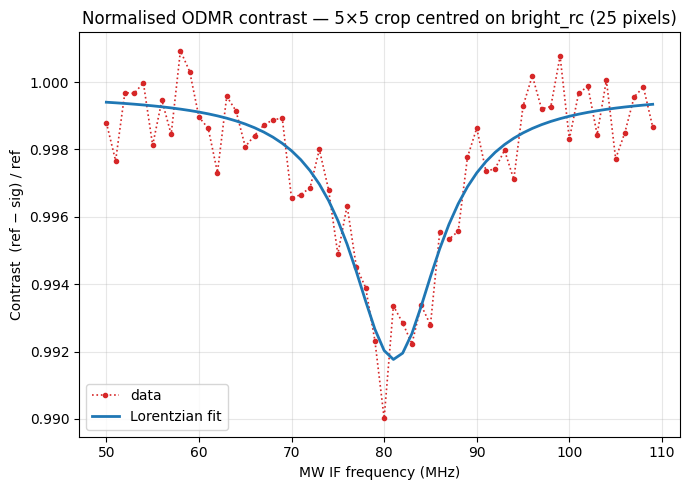

In [ ]:
# Integrated contrast signal over 5x5 pixel crop centred on bright_rc (25 pixels)
f_mhz = f_vec / 1e6

r0, c0 = bright_rc
ref_roi_all = []
std_roi_all = []
contrast_roi_all = []

for k in range(len(n_complete_reps_all)):
    sig_roi = sig_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))
    ref_roi = ref_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))
    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_roi = np.where(ref_roi != 0, 1 - (ref_roi - sig_roi) / ref_roi, 0.0)
    ref_roi_all.append(np.mean(ref_roi))
    std_roi_all.append(np.std(ref_roi))
    contrast_roi_all.append(contrast_roi)

contrast_roi_avg = np.mean(contrast_roi_all, axis=0)


fit_res_roi = fitter.fit_cw_odmr(f_vec, -(contrast_roi_avg - 1), lo_hz=0)
y_fit_roi = 1.0 - np.asarray(fit_res_roi.y_fit, dtype=float)

# f_range = f_mhz[-1] - f_mhz[0]
# edge_mask = (f_mhz < f_mhz[0] + 0.2*f_range) | (f_mhz > f_mhz[-1] - 0.2*f_range)
# noise_roi = np.std(contrast_roi_avg[edge_mask])
noise_roi = np.mean(std_roi_all)
ref_avg_roi = np.mean(ref_roi_all)

SNR_roi = ref_avg_roi*np.abs(fit_res_roi.params['amplitude']) / noise_roi if noise_roi > 0 else np.inf


plt.figure(figsize=(7, 5))
plt.plot(f_mhz, contrast_roi_avg, 'o:', ms=3, lw=1.2, color='C3', label='data')
plt.plot(f_mhz, y_fit_roi, '-', lw=2, color='C0', label='Lorentzian fit')
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('Contrast  (ref − sig) / ref')
plt.title('Normalised ODMR contrast — 5×5 crop centred on bright_rc (25 pixels)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print('Fit results (5×5 ROI):')
print(f"- f0:        {fit_res_roi.params['f0_hz']/1e6:.6f} MHz")
print(f"- FWHM:      {fit_res_roi.params['fwhm_hz']/1e6:.6f} MHz")
print(f"- amplitude: {ref_avg_roi*fit_res_roi.params['amplitude']:.6g}")
print(f"- Noise: {noise_roi:.6g}")
print(f"- SNR:       {SNR_roi:.2f}")


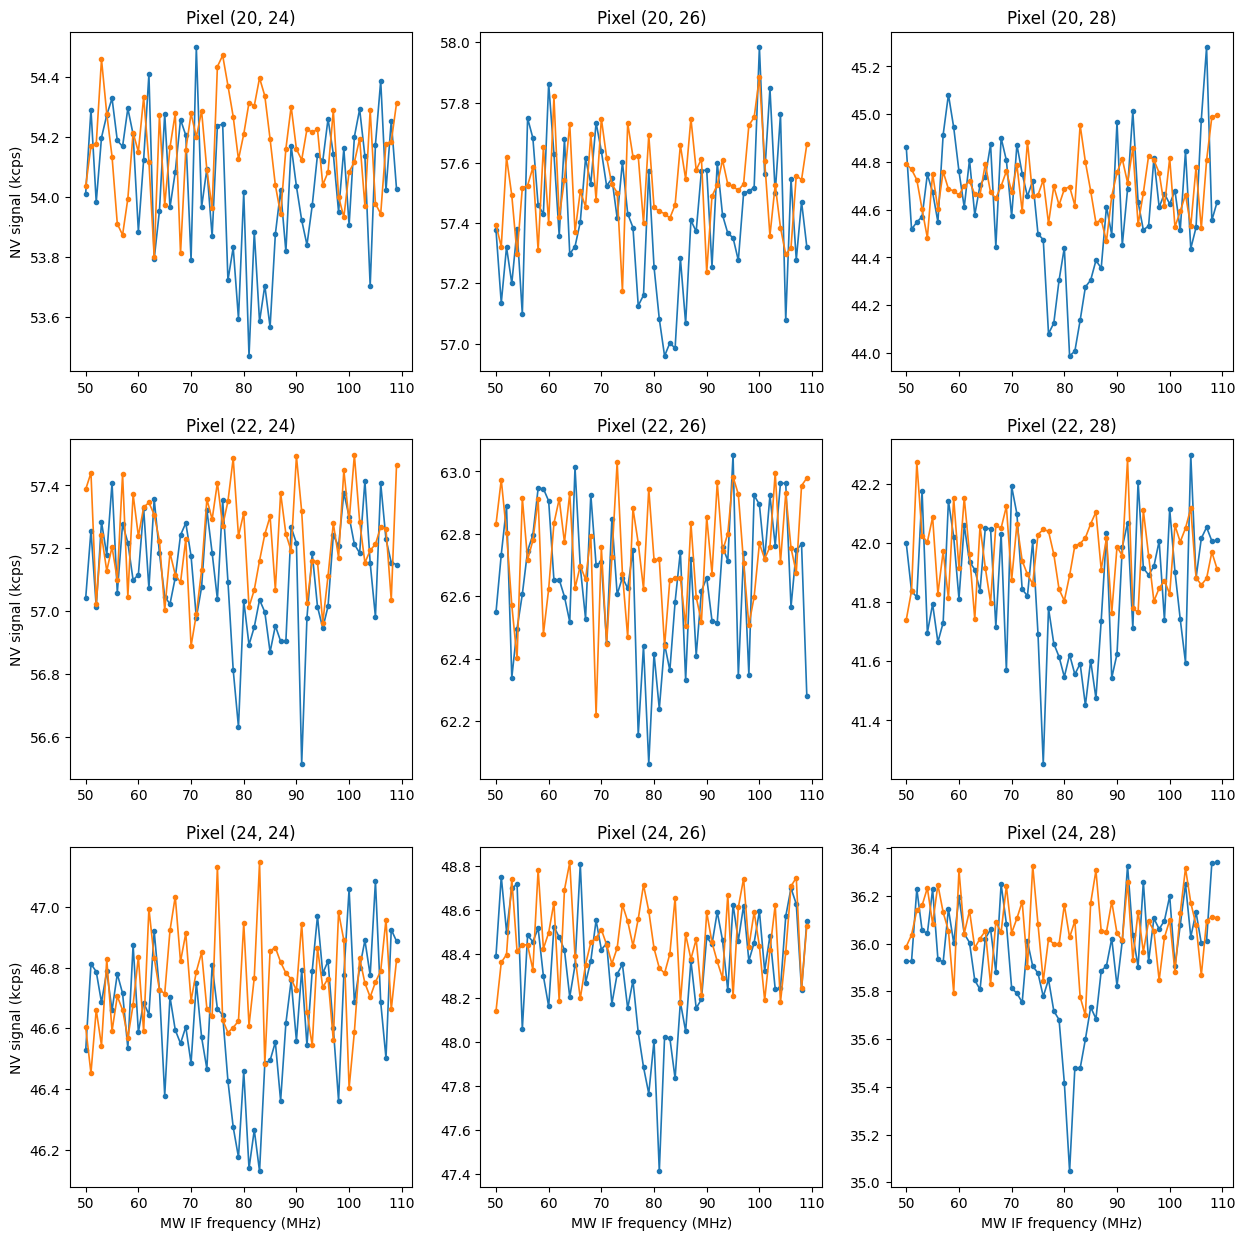

In [216]:
#plot contrast signal for 3X3 grid with fixed center pixel
bright_rc = (22,26)

f_mhz = f_vec / 1e6
plt.subplots(3, 3, figsize=(15, 15))
snr_all = []


for i in range(3):
    for j in range(3):

        sig_norm_pix_all = []
        sig_pix_all = []
        ref_pix_all = []
        for k in range(len(n_complete_reps_all)):
            #ref_frame = (ref_avg_cps_bgsub_all[k,:,:,:]).mean(axis =0)  # (rows, cols) — mean reference over all frequencies
            #bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
            #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
            sig_pix = (sig_avg_cps_bgsub_all[k,:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            ref_pix = (ref_avg_cps_bgsub_all[k,:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            sig_pix_all.append(sig_pix)
            ref_pix_all.append(ref_pix)
            sig_norm_pix_all.append(1-((ref_pix - sig_pix) / ref_pix))

        sig_pix_all = np.array(sig_pix_all)
        ref_pix_all = np.array(ref_pix_all)
        sig_pix_avg = np.mean(sig_pix_all, axis=0)
        ref_pix_avg = np.mean(ref_pix_all, axis=0)
        sig_norm_pix_all = np.array(sig_norm_pix_all)
        sig_norm_pix_avg = np.mean(sig_norm_pix_all, axis=0)
        #calculate SNR
        # f_range = f_mhz[-1] - f_mhz[0]
        # sigma = np.std(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        # baseline = np.mean(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        # amp = baseline - sig_norm_pix_avg.min()
        # snr = amp / sigma if sigma > 0 else np.inf
        # snr_all.append(snr)

            
        plt.subplot(3, 3, i*3 + j + 1)
        plt.plot(f_mhz, sig_pix_avg/1000, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(f_mhz, ref_pix_avg/1000, 'o-', ms=3, lw=1.2, label='Reference')
        #plt.ylim(min(sig_norm_pix_avg.min(), ref.min()) * 0.95 *1e-3, max(sig_norm_pix_avg.max(), ref.max()) * 1.05 *1e-3)
        #plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2}) SNR={snr:.2f}')
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        #plt.ylim(0.94,1.02)
        
        #plt.title(f'SNR={snr:.2f}')
        if i==2:
            plt.xlabel('MW IF frequency (MHz)')
        if j==0:
            plt.ylabel('NV signal (kcps)')
        #for k in range(len(n_complete_reps_all)):
#print("Average SNR across ROI:", np.mean(snr_all))

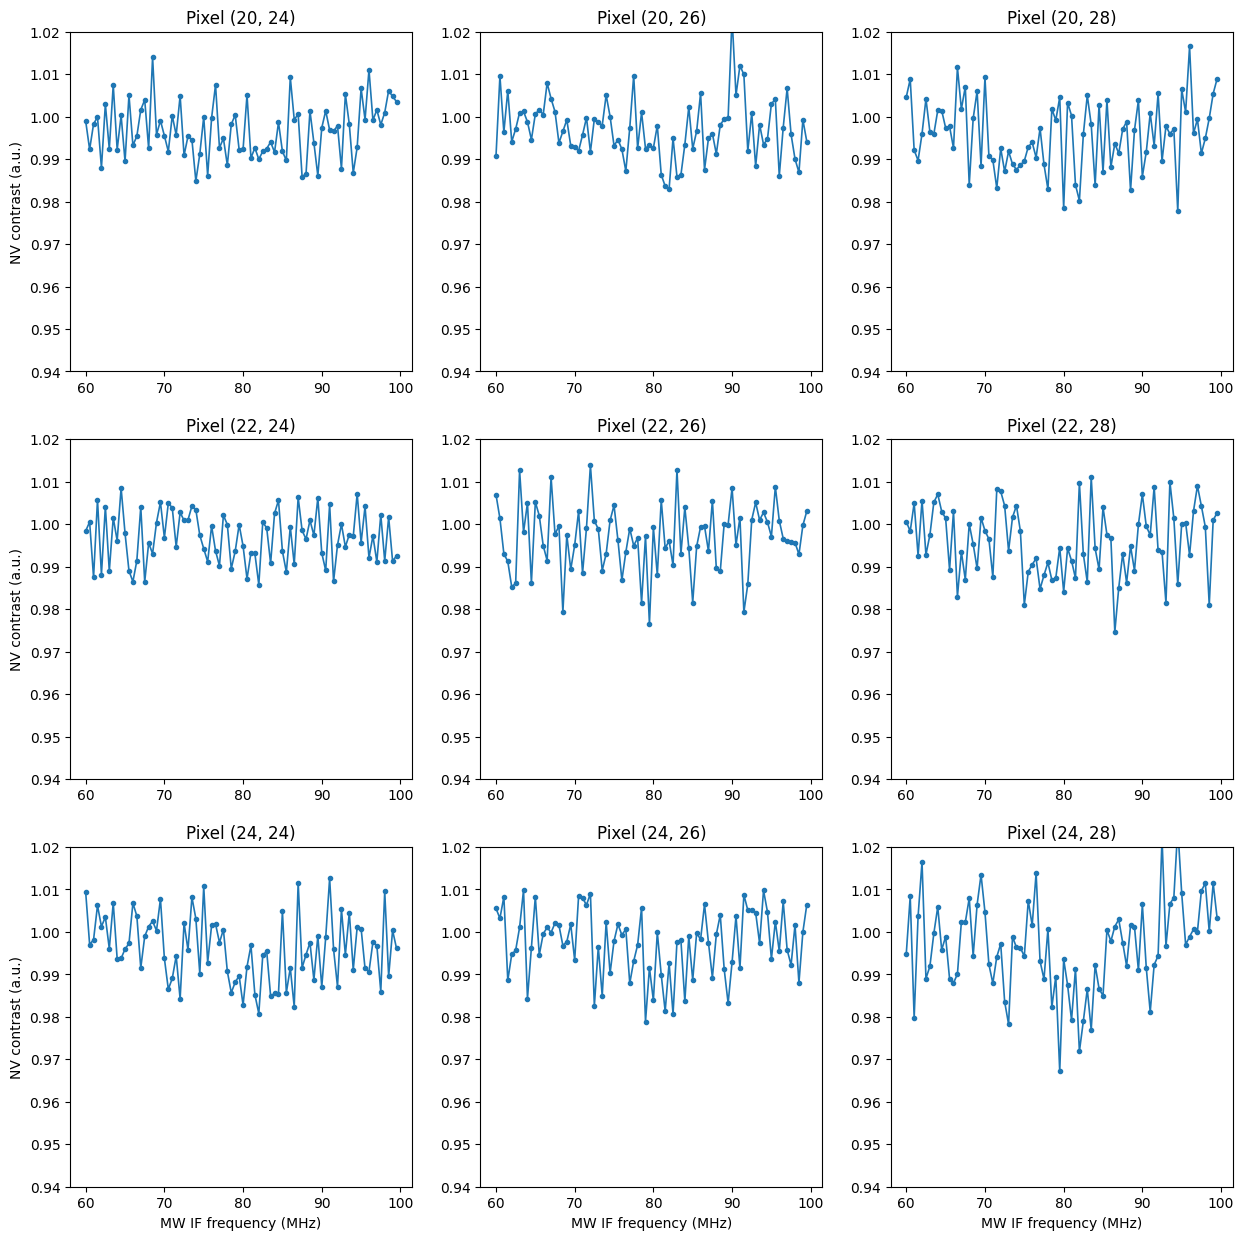

In [159]:
#plot contrast signal for 3X3 grid with fixed center pixel
bright_rc = (22,26)

f_mhz = f_vec / 1e6
plt.subplots(3, 3, figsize=(15, 15))
snr_all = []

for i in range(3):
    for j in range(3):

        sig_norm_pix_all = []
        for k in range(len(n_complete_reps_all)):
            #ref_frame = (ref_avg_cps_bgsub_all[k,:,:,:]).mean(axis =0)  # (rows, cols) — mean reference over all frequencies
            #bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
            #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
            sig_pix = (sig_avg_cps_bgsub_all[k,:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            ref_pix = (ref_avg_cps_bgsub_all[k,:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            sig_norm_pix_all.append(1-((ref_pix - sig_pix) / ref_pix))
      
        sig_norm_pix_all = np.array(sig_norm_pix_all)
        sig_norm_pix_avg = np.mean(sig_norm_pix_all, axis=0)
        #calculate SNR
        # f_range = f_mhz[-1] - f_mhz[0]
        # sigma = np.std(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        # baseline = np.mean(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        # amp = baseline - sig_norm_pix_avg.min()
        # snr = amp / sigma if sigma > 0 else np.inf
        # snr_all.append(snr)

            
        plt.subplot(3, 3, i*3 + j + 1)
        plt.plot(f_mhz, sig_norm_pix_avg, 'o-', ms=3, lw=1.2, label='Signal')
        #plt.ylim(min(sig_norm_pix_avg.min(), ref.min()) * 0.95 *1e-3, max(sig_norm_pix_avg.max(), ref.max()) * 1.05 *1e-3)
        #plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2}) SNR={snr:.2f}')
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        plt.ylim(0.94,1.02)
        #plt.title(f'SNR={snr:.2f}')
        if i==2:
            plt.xlabel('MW IF frequency (MHz)')
        if j==0:
            plt.ylabel('NV contrast (a.u.)')
        #for k in range(len(n_complete_reps_all)):
#print("Average SNR across ROI:", np.mean(snr_all))

Pixel (20, 24) fit results:
- f0: 78.196005 MHz
- FWHM: 2177.803336 MHz
- amplitude: 19.1331
- SNR: 3141.58
Pixel (20, 26) fit results:
- f0: 82.000000 MHz
- FWHM: 27.500000 MHz
- amplitude: nan
- SNR: inf
Pixel (20, 28) fit results:
- f0: 79.539004 MHz
- FWHM: 669.922666 MHz
- amplitude: 2.75455
- SNR: 363.20
Pixel (22, 24) fit results:
- f0: 99.234724 MHz
- FWHM: -0.010409 MHz
- amplitude: 11.0558
- SNR: 1874.53
Pixel (22, 26) fit results:
- f0: 79.434159 MHz
- FWHM: 0.308066 MHz
- amplitude: 0.0242888
- SNR: 3.25
Pixel (22, 28) fit results:
- f0: 78.150089 MHz
- FWHM: 5.312862 MHz
- amplitude: 0.0106921
- SNR: 1.40
Pixel (24, 24) fit results:
- f0: 82.301662 MHz
- FWHM: 8.568807 MHz
- amplitude: 0.0116057
- SNR: 1.68
Pixel (24, 26) fit results:
- f0: 81.210741 MHz
- FWHM: 6.845298 MHz
- amplitude: 0.0119997
- SNR: 1.70
Pixel (24, 28) fit results:
- f0: 81.581461 MHz
- FWHM: 6.189354 MHz
- amplitude: 0.0213911
- SNR: 2.35
Average SNR across all pixels: inf


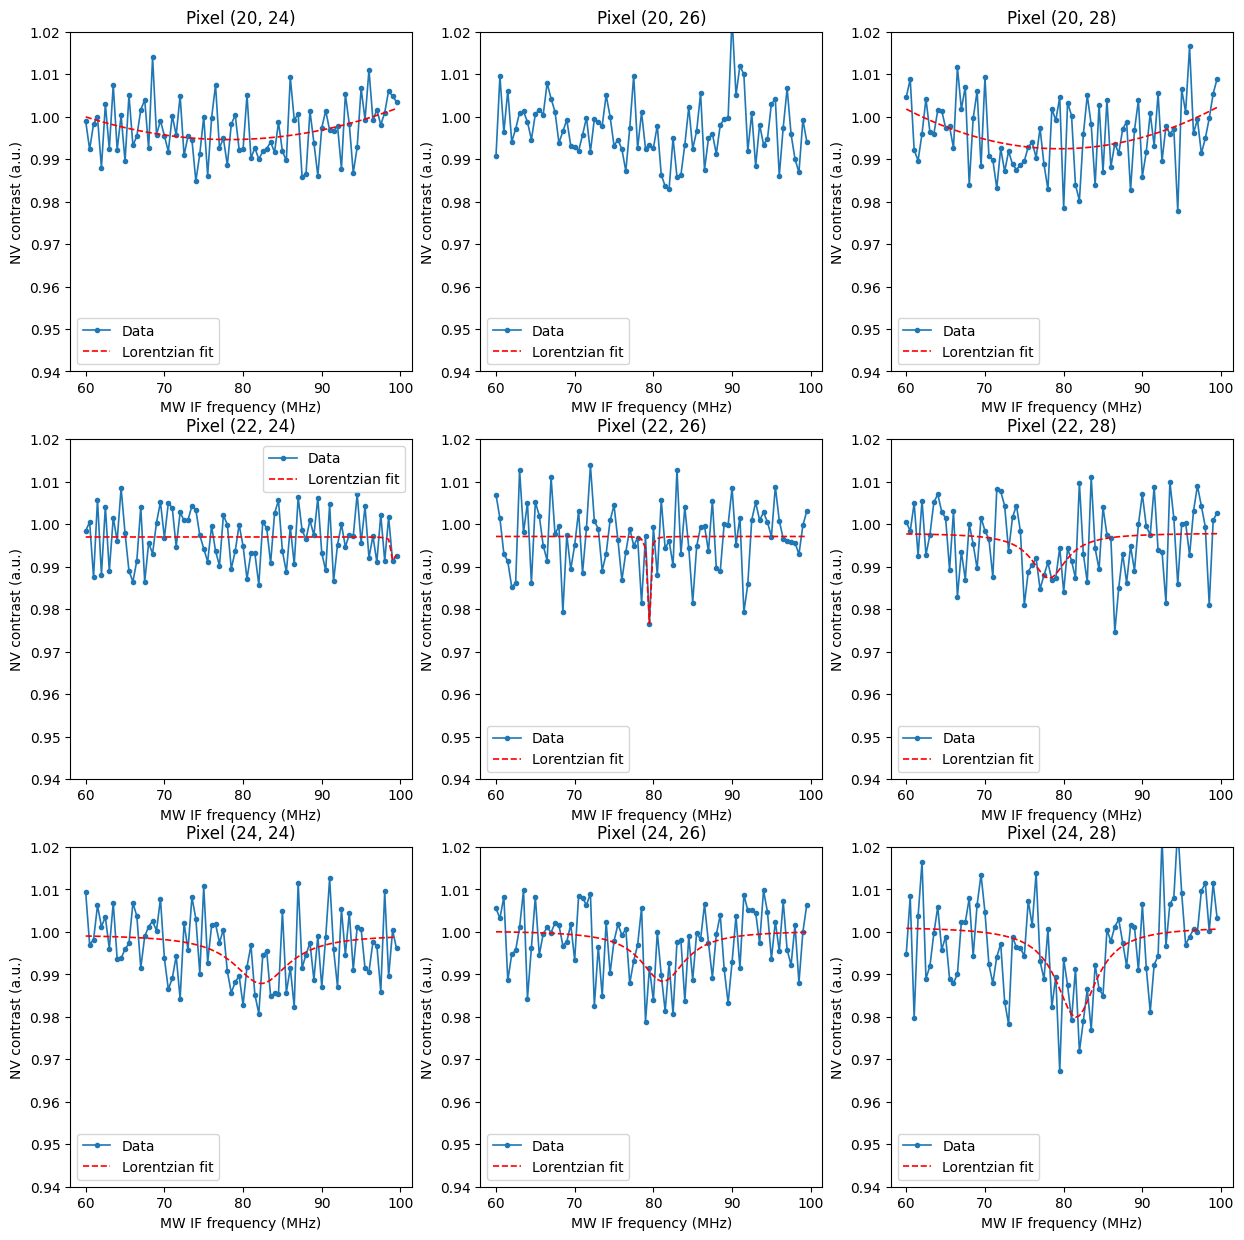

In [160]:
#fit lorentzian to contrast signal for each pixel 

reload(fits)
fitter = fits.ExperimentFitter()
plt.subplots(3, 3, figsize=(15, 15))

fit_res_all = []
SNR_all = []

for i in range(3):
    for j in range(3):
        sig_norm_pix_all = []
        for k in range(len(n_complete_reps_all)):
            sig_pix = (sig_avg_cps_bgsub_all[k,:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            ref_pix = (ref_avg_cps_bgsub_all[k,:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            sig_norm_pix_all.append(1-((ref_pix - sig_pix) / ref_pix))
      
        sig_norm_pix_all = np.array(sig_norm_pix_all)
        sig_norm_pix_avg = np.mean(sig_norm_pix_all, axis=0)

        fit_res = fitter.fit_cw_odmr(f_vec, -(sig_norm_pix_avg-1), lo_hz=0)
        fit_res_all.append(fit_res)

        x_hz = getattr(fit_res, 'x', None)
        y_contrast = getattr(fit_res, 'y', None)
        y_fit = getattr(fit_res, 'y_fit', None)
        x_hz = f_vec
        y_contrast = sig_norm_pix_avg
        x_mhz = np.asarray(x_hz, dtype=float) / 1e6

        resid = y_contrast - (1.0 - np.asarray(y_fit, dtype=float))
        resid_rms = np.sqrt(np.mean(resid**2))
        SNR = np.abs(fit_res.params['amplitude']) / resid_rms if resid_rms > 0 else np.inf
        SNR_all.append(SNR)

        plt.subplot(3, 3, i*3 + j + 1)
        plt.plot(x_mhz, y_contrast, 'o-', ms=3, lw=1.2, label='Data')
        plt.plot(x_mhz,  1.0 - np.asarray(y_fit, dtype=float), 'r--', lw=1.2, label='Lorentzian fit')
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('NV contrast (a.u.)')
        plt.ylim(0.94,1.02)
        plt.legend()

        print(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2}) fit results:')
        print(f"- f0: {fit_res.params['f0_hz']/1e6:.6f} MHz")
        print(f"- FWHM: {fit_res.params['fwhm_hz']/1e6:.6f} MHz")
        print(f"- amplitude: {fit_res.params['amplitude']:.6g}")
        print(f"- SNR: {SNR:.2f}")

print("Average SNR across all pixels:", np.mean(SNR_all))
        

In [ ]:
#colormap of fitted ODMR dip amplitude across 3x3 grid of pixels
plt.figure(figsize=(6, 5))
freq_grid = np.zeros((3,3))
for idx, fit_res in enumerate(fit_res_all):
    i = idx // 3
    j = idx % 3
    freq_grid[i,j] = fit_res.params['f0_hz']
plt.imshow(freq_grid, cmap = 'inferno')
#print freq values in each pixel 
for i in range(3):
    for j in range(3):
        print(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2}): f0 = {freq_grid[i,j]/1e6:.6f} MHz')
        plt.text(j, i, f'{freq_grid[i,j]/1e6:.6f} MHz', ha='center', va='center', color='white', fontsize=8)
#set colorbar limits to 0.99x min and 1.01x max of freq_grid values
plt.clim(0.99*freq_grid.min(), 1.01*freq_grid.max())
plt.colorbar(label='Fitted ODMR dip frequency (Hz)')
plt.title('ODMR Dip Frequency Map')


In [ ]:
n = 5
f_mhz = f_vec / 1e6
plt.subplots(n, n, figsize=(6*n, 6*n))
snr_all = []

for i in range(n):
    for j in range(n):
        sig_pix_all = []
        ref_pix_all = []
        sig_norm_pix_all = []
        for k in range(len(n_complete_reps_all)):
            ref_frame = (ref_avg_cps_bgsub_all[k,:,:,:]).mean(axis =0)  # (rows, cols) — mean reference over all frequencies
            bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
            #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
            sig_pix_all.append(sig_avg_cps_bgsub_all[k,:, bright_rc[0]-int(n/2)+i, bright_rc[1]-int(n/2)+j])
            ref_pix_all.append(ref_avg_cps_bgsub_all[k,:, bright_rc[0]-int(n/2)+i, bright_rc[1]-int(n/2)+j])
            sig_norm_pix_all.append(1-((ref_pix_all[-1] - sig_pix_all[-1]) / ref_pix_all[-1]))
        sig_pix_all = np.array(sig_pix_all)
        ref_pix_all = np.array(ref_pix_all)
        sig_norm_pix_all = np.array(sig_norm_pix_all)
        #print(sig_norm_pix_all.shape)
        sig_pix_avg = np.mean(sig_pix_all, axis=0) 
        ref_pix_avg = np.mean(ref_pix_all, axis=0)
        sig_norm_pix_avg = np.mean(sig_norm_pix_all, axis=0)
        #calculate SNR
        f_range = f_mhz[-1] - f_mhz[0]
        sigma = np.std(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        baseline = np.mean(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        amp = baseline - sig_norm_pix_avg.min()
        snr = amp / sigma if sigma > 0 else np.inf
        snr_all.append(snr)

            
        plt.subplot(n, n, i*n + j + 1)
        plt.plot(f_mhz, sig_pix_avg*1e-3, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(f_mhz, ref_pix_avg*1e-3, 'o-', ms=3, lw=1.2, label='Reference')
        #plt.ylim(min(sig_norm_pix_avg.min(), ref.min()) * 0.95 *1e-3, max(sig_norm_pix_avg.max(), ref.max()) * 1.05 *1e-3)
        #plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)}) SNR={snr:.2f}')
        #plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('NV signal (kcps)')
        #for k in range(len(n_complete_reps_all)):
print("Average SNR across ROI:", np.mean(snr_all))

In [ ]:
n = 5
f_mhz = f_vec / 1e6
plt.subplots(n, n, figsize=(6*n, 6*n))
snr_all = []

for i in range(n):
    for j in range(n):
        sig_pix_all = []
        ref_pix_all = []
        sig_norm_pix_all = []
        for k in range(len(n_complete_reps_all)):
            ref_frame = (ref_avg_cps_bgsub_all[k,:,:,:]).mean(axis =0)  # (rows, cols) — mean reference over all frequencies
            bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
            #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
            sig_pix_all.append(sig_avg_cps_bgsub_all[k,:, bright_rc[0]-int(n/2)+i, bright_rc[1]-int(n/2)+j])
            ref_pix_all.append(ref_avg_cps_bgsub_all[k,:, bright_rc[0]-int(n/2)+i, bright_rc[1]-int(n/2)+j])
            sig_norm_pix_all.append(1-((ref_pix_all[-1] - sig_pix_all[-1]) / ref_pix_all[-1]))
      
        sig_norm_pix_all = np.array(sig_norm_pix_all)
        sig_norm_pix_avg = np.mean(sig_norm_pix_all, axis=0)
        #calculate SNR
        f_range = f_mhz[-1] - f_mhz[0]
        sigma = np.std(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        baseline = np.mean(sig_norm_pix_avg[(f_mhz < f_mhz[0] + 0.1*f_range) | (f_mhz > f_mhz[-1] - 0.1*f_range)])
        amp = baseline - sig_norm_pix_avg.min()
        snr = amp / sigma if sigma > 0 else np.inf
        snr_all.append(snr)

            
        plt.subplot(n, n, i*n + j + 1)
        plt.plot(f_mhz, sig_norm_pix_avg, 'o-', ms=3, lw=1.2, label='Signal')
        #plt.ylim(min(sig_norm_pix_avg.min(), ref.min()) * 0.95 *1e-3, max(sig_norm_pix_avg.max(), ref.max()) * 1.05 *1e-3)
        #plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)}) SNR={snr:.2f}')
        plt.ylim(0.935,1.02)
        plt.title(f'SNR={snr:.2f}')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('NV contrast (a.u.)')
        #for k in range(len(n_complete_reps_all)):
print("Average SNR across ROI:", np.mean(snr_all))

In [ ]:
#fit Lorentzian to each pixel's contrast curve to extract amplitude, resonance frequency, and linewidth
from scipy.optimize import curve_fit
def lorentzian(f, f0, gamma, A, C):
    return A * (gamma**2 / ((f - f0)**2 + gamma**2)) + C
f0s = np.zeros((n, n))
gammas = np.zeros((n, n))
amps = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        contrast = np.where(ref != 0, (ref - sig) / ref, 0.0)

        try:
            popt, _ = curve_fit(lorentzian, f_mhz, contrast, p0=[f_mhz[np.argmin(contrast)], 10, contrast.min(), contrast.max()])
            f0s[i, j], gammas[i, j], amps[i, j] = popt[0], popt[1], popt[2]
        except RuntimeError:
            f0s[i, j], gammas[i, j], amps[i, j] = np.nan, np.nan, np.nan

    
# Plot fitted contrast amplitude, resonance frequency, and linewidth for each pixel in the ROI
plt.figure()
plt.imshow(amps, cmap='viridis', extent=[bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5, bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5])
plt.colorbar(label='Amplitude')
plt.title('Fitted Amplitudes')
plt.show()


In [ ]:
#plot histogram of amplitudes
plt.figure()
plt.hist(amps.flatten(), bins=20, color='C1', edgecolor='k')
plt.xlabel('Amplitude')
plt.ylabel('Count')
plt.title('Histogram of Fitted Amplitudes')
plt.show()